In [307]:
#2-1필요한 라이브러리 호출
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#2-2데이터 호출
dataset = pd.read_csv("C:/Users/user/OneDrive/바탕 화면/car_evaluation.csv")
dataset.head()#처음 (기본 값 5)n개 출력

,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [308]:
dataset.tail()#마지막 (기본 값 5)n개 출력

,price,maint,doors,persons,lug_capacity,safety,output
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good
1727,low,low,5more,more,big,high,vgood


<Axes: >

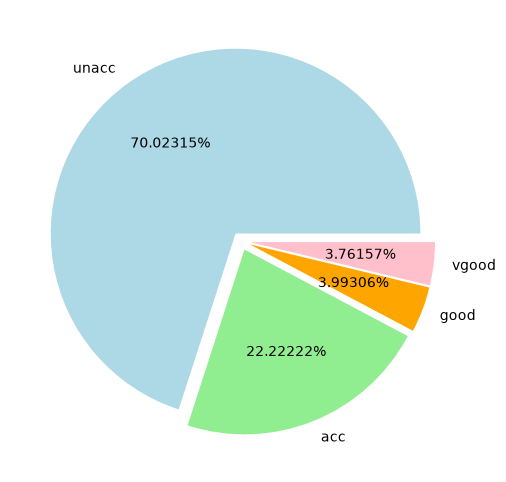

In [309]:
#2-3 예제 데이터셋 분포
fig_size = plt.rcParams["figure.figsize"]
fig_size[0]=8
fig_size[1]=6
plt.rcParams["figure.figsize"] = fig_size
dataset.output.value_counts().plot(kind='pie', autopct='%0.05f%%',
colors=['lightblue', 'lightgreen', 'orange', 'pink'], explode=(0.05, 0.05, 0.05, 0.05))


In [310]:
#2-4 데이터를 범주형 타임으로 변환
categorical_colums = ['price','maint','doors','persons','lug_capacity','safety']

for category in categorical_colums:
    dataset[category] = dataset[category].astype('category') # astype() 메서드를 이용하여 데이터를 범주형으로 변환

#cat.codes를 사용하여 범주형 데이터를 숫자로 변환
price = dataset['price'].cat.codes.values
maint = dataset['maint'].cat.codes.values
doors = dataset['doors'].cat.codes.values
persons = dataset['persons'].cat.codes.values
lug_capacity = dataset['lug_capacity'].cat.codes.values
safety = dataset['safety'].cat.codes.values

categorical_data = np.stack([price,	maint,	doors,	persons,	lug_capacity,	safety], 1)
categorical_data[:10]

array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

In [311]:
#2-5배열을 텐서로 변환
categorical_data = torch.tensor(categorical_data, dtype=torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

In [312]:
#2-6 레이블로 사용할 칼럼을 텐서로 변환
outputs = pd.get_dummies(dataset.output)#get_dummies는 가변수로 변환시키는 함수
outputs = outputs.values
outputs = torch.tensor(outputs).flatten()

print(categorical_data.shape)
print(outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


In [313]:
#2-7 범주형 칼럼을 N차원으로 변환
categorical_colums_sizes = [len(dataset[column].cat.categories) for column in categorical_colums]
categorical_embedding_sizes = [(col_size, min(50, col_size+1)//2) for col_size in categorical_colums_sizes]
print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


In [314]:
#2-8 데이터셋 분리
total_records = 1728
test_records = int(total_records * .2)

categorical_train_data = categorical_data[:total_records - test_records]
categorical_test_data = categorical_data[total_records - test_records:total_records]
train_outputs = outputs[:total_records - test_records]
test_outputs = outputs[total_records - test_records:total_records]

In [315]:
#2-9 데이터셋 분리 확인
print(len(categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))

1383
1383
345
345


In [316]:
#2-10 모댈의 네트웨크 생성
class Model(nn.Module):
    def __init__(self, embedding_size, output_size, layers, p=0.5):
        super().__init__()
        self.all_embeddings = nn.ModuleList([nn.Embedding(ni, nf) for ni, nf in embedding_size])

        self.embedding_dropout = nn.Dropout(p)

        all_layers = []
        num_categorical_cols = sum((nf for ni, nf in embedding_size))
        input_size = num_categorical_cols

        for i in layers:
            all_layers.append(nn.Linear(input_size, i))
            all_layers.append(nn.ReLU(inplace=True))
            all_layers.append(nn.BatchNorm1d(i))
            all_layers.append(nn.Dropout(p))
            input_size = i

        all_layers.append(nn.Linear(layers[-1], output_size))
        self.layers = nn.Sequential(*all_layers)


    def forward(self, x_categorical):
        embeddings = []
        for i,e in enumerate(self.all_embeddings):
            embeddings.append(e(x_categorical[:,i]))
        x = torch.cat(embeddings, 1)
        x = self.embedding_dropout(x)
        x = self.layers(x)
        return x

In [317]:
#2-11 Model 클래스의 객체 생성, 은닉층을 [200,100,50]으로 정의했지만 다른 크기로 지정해 테스트할 수 있음
model = Model(categorical_embedding_sizes, 4, [200,100,50], p =0.1)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.1, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


In [318]:
#2-12 모델의 파라미터 정의
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [319]:
#2-13 CPU/GPU 사용 지정
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
    
print(device)

cuda


In [320]:
#2-14 모델 학습
epochs = 2000
aggregated_losses = []
train_outputs = train_outputs.to(device=device, dtype=torch.int64)
for i in range(epochs): #for반복문은 500회 반복되며 각 반복마다 손실 함수가 오차를 계산
    i += 1
    y_pred = model(categorical_train_data).to(device)
    single_loss = loss_function(y_pred, train_outputs)
    aggregated_losses.append(single_loss)#반복할 때마다 오차를 aggregated_losses에 추가

    if i%25 == 1:
        print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

    optimizer.zero_grad()
    single_loss.backward()#가중치를 업데이트 하기 위해 호출
    optimizer.step()#기울기 업데이트

print(f'epoch: {i:3} loss: {single_loss.item():10.10f}')

epoch:   1 loss: 1.44889355
epoch:  26 loss: 1.19703555
epoch:  51 loss: 1.01065159
epoch:  76 loss: 0.81354225
epoch: 101 loss: 0.57349497
epoch: 126 loss: 0.45113030
epoch: 151 loss: 0.39781421
epoch: 176 loss: 0.33203414
epoch: 201 loss: 0.31322506
epoch: 226 loss: 0.26853010
epoch: 251 loss: 0.28032681
epoch: 276 loss: 0.22937047
epoch: 301 loss: 0.25173137
epoch: 326 loss: 0.23303232
epoch: 351 loss: 0.22542225
epoch: 376 loss: 0.22446798
epoch: 401 loss: 0.19893982
epoch: 426 loss: 0.17888121
epoch: 451 loss: 0.20652714
epoch: 476 loss: 0.20488395
epoch: 501 loss: 0.18508296
epoch: 526 loss: 0.18120334
epoch: 551 loss: 0.17971796
epoch: 576 loss: 0.18447730
epoch: 601 loss: 0.17322026
epoch: 626 loss: 0.16027430
epoch: 651 loss: 0.16573519
epoch: 676 loss: 0.17345026
epoch: 701 loss: 0.15965717
epoch: 726 loss: 0.14802925
epoch: 751 loss: 0.15703110
epoch: 776 loss: 0.14094099
epoch: 801 loss: 0.15253803
epoch: 826 loss: 0.13356553
epoch: 851 loss: 0.14907810
epoch: 876 loss: 0.1

In [321]:
#2-15 테스트 데이터셋으로 모델 예측
#model, categorical_test_data, test_outputs 같은 곳에 위치(GPU를 사용하고 있어서)
model = model.to(device)
categorical_test_data = categorical_test_data.to(device)
test_outputs = test_outputs.to(device=device, dtype=torch.int64)
with torch.no_grad():
    y_val = model(categorical_test_data)
    loss = loss_function(y_val, test_outputs)
print(f'Loss: {loss:.8f}')

Loss: 0.22510840


In [322]:
#2-16 모델의 예측 확인
print(y_val[:5])

tensor([[ 8.3908, -7.2641, -4.5683, -4.3864],
        [ 4.0809,  3.9322, -5.5506, -5.9746],
        [ 3.2776,  2.2722, -4.8653, -4.8541],
        [-0.6871,  8.2275, -3.1953, -3.6433],
        [ 4.3530,  2.1020, -5.3782, -4.8926]], device='cuda:0')


In [323]:
#2-17 가장 큰 값을 같즌 인덱스 확인
y_val = torch.argmax(y_val, axis=1)#GPU사용하기에 torch사용
print(y_val[:5])

tensor([0, 0, 0, 1, 0], device='cuda:0')


In [ ]:
#2-18 테스트 데이터셋을 이용한 정확도 확인
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#GPU에서 수행하기 위해
test_outputs_cpu = test_outputs.cpu().numpy()
y_val_cpu = y_val.cpu().numpy()

print(confusion_matrix(test_outputs_cpu,y_val_cpu))
print(classification_report(test_outputs_cpu,y_val_cpu))
print(accuracy_score(test_outputs_cpu,y_val_cpu))

#recall, precision, F1-score도 확인

[[250   9]
 [ 18  68]]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       259
           1       0.88      0.79      0.83        86

    accuracy                           0.92       345
   macro avg       0.91      0.88      0.89       345
weighted avg       0.92      0.92      0.92       345

0.9217391304347826
